## 2D Poisson equation via Deep Ritz (square domain; manufactured solution)

We consider a standard 2D Poisson problem on the square domain $\Omega = (-1,1)^2$ with homogeneous Dirichlet boundary conditions:
$$
\begin{cases}
-\Delta u(x,y) = f(x,y), & (x,y)\in\Omega,\\
u(x,y) = 0, & (x,y)\in\partial\Omega.
\end{cases}
$$

### Deep Ritz formulation (Yu & E spirit)

Following the Deep Ritz method (Yu & E, 2017), we approximate the solution by a parametric model $u_\theta$ and minimize the variational energy
$$
\mathcal{L}_{\mathrm{DR},\Omega}(u_\theta)=\int_{\Omega}\left(\tfrac12\,|\nabla u_\theta|^2 - f\,u_\theta\right)\,dx,
$$
where $|\nabla u_\theta|^2 = (\partial_x u_\theta)^2 + (\partial_y u_\theta)^2$ and $-\Delta u_\theta = -(\partial_{xx}u_\theta + \partial_{yy}u_\theta)$ are treated *symmetrically* in $x$ and $y$.

The Dirichlet condition is enforced weakly via a quadratic penalty:
$$
\mathcal{L}_{\mathrm{DR}}(u_\theta)=\mathcal{L}_{\mathrm{DR},\Omega}(u_\theta) + \frac{\lambda_{\mathrm{bc}}}{2}\int_{\partial\Omega} u_\theta^2\,ds.
$$

### Manufactured smooth test case

To enable exact, smooth diagnostics (and to avoid geometric/singularity effects), we use the manufactured solution

$$
u_{\mathrm{exact}}(x,y)=\sin(\pi x)\sin(\pi y),
$$
which satisfies $u_{\mathrm{exact}}=0$ on $\partial\Omega$, and yields the forcing
$$
f(x,y)=2\pi^2\sin(\pi x)\sin(\pi y).
$$

### Diagnostics (Yu & E–style)

We track the same convergence quantities typically reported for Deep Ritz Poisson benchmarks:
- training objective value versus epochs ($\mathcal{L}_{\mathrm{DR}}$),
- relative $L^2(\Omega)$ error $\|u_\theta-u_{\mathrm{exact}}\|_{L^2}/\|u_{\mathrm{exact}}\|_{L^2}$,
- $L^2(\Omega)$ norm of the strong-form residual $\|-\Delta u_\theta - f\|_{L^2(\Omega)}$,
- boundary violation in $L^2(\partial\Omega)$ and $L^\infty(\partial\Omega)$.

All derivatives are obtained by analytic propagation through the photonic model (no finite differences).

In [10]:
# Install dependencies (run once per kernel / environment)
!pip install -q \
    numpy==1.26.4 \
    numba \
    neuroptica \
    matplotlib==3.8.4


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
# Environment sanity + imports
import os
import sys
import platform

# Best-effort to reduce numerical non-determinism from BLAS threading.
# Must be set before importing numpy in the kernel session to be most effective.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import neuroptica as neu
import numpy as np
from neuroptica.components import MZI, PhaseShifter
from neuroptica.layers import OpticalMeshNetworkLayer, Activation, DropMask
import matplotlib.pyplot as plt

print("Python executable:", sys.executable)
print("Platform:", platform.platform())
print("NumPy:", np.__version__)

Python executable: c:\Users\yosef.benchedly\AppData\Local\Programs\Python\Python312\python.exe
Platform: Windows-11-10.0.26200-SP0
NumPy: 1.26.4


In [12]:
# We define the holomorphic complex nonlinearity: phi(z) = z^2.
# It is used both in standard backpropagation algorithm and in the x-derivative propagation helper.

class ComplexSquared(neu.Nonlinearity):
    def __init__(self, N: int):
        super().__init__(N)

    def forward_pass(self, X: np.ndarray) -> np.ndarray:
        return X**2

    def backward_pass(self, gamma: np.ndarray, Z: np.ndarray) -> np.ndarray:
        # For phi(z)=z^2, dphi/dz = 2z
        return gamma * (2 * Z)

In [13]:
# 2D Poisson: diagnostics utilities (NumPy + matplotlib only)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

def l2_norm_trapz_2d(z: np.ndarray, x: np.ndarray, y: np.ndarray) -> float:
    """Approximate ||z||_{L^2(Ω)} via sqrt(∫∫ z^2 dx dy) on a tensor grid (trapz).
    z is assumed sampled on the full tensor grid defined by 1D arrays x and y.
    """
    z = np.asarray(z, dtype=np.float64)
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    ix = np.trapz(z * z, x, axis=1)
    ixy = np.trapz(ix, y, axis=0)
    return float(np.sqrt(ixy))

def boundary_rmse(u_b: np.ndarray) -> float:
    """RMSE on a boundary sample set (proxy for L^2(∂Ω) up to sampling/measure constants)."""
    u_b = np.asarray(u_b, dtype=np.float64).reshape(-1)
    return float(np.sqrt(np.mean(u_b * u_b)))

def boundary_linf(u_b: np.ndarray) -> float:
    u_b = np.asarray(u_b, dtype=np.float64).reshape(-1)
    return float(np.max(np.abs(u_b)))

In [14]:
# 2D helpers (minimal; used only by the 2D experiment below)
import numpy as np
import neuroptica as neu
import neuroptica.nonlinearities as nl

def build_photonic_model_2d(
    N: int = 12,
    depth: int = 2,
    seed: int = 0,
    activation: str = 'square',
) -> neu.Sequential:
    """Photonic model for 2D inputs (x,y,1) embedded into N modes.

    activation options (holomorphic-friendly):
    - 'square': uses ComplexSquared (z^2)
    - 'sigmoid': uses neuroptica.nonlinearities.Sigmoid

    Note: if you change activation, the 2D derivative pass must support it.
    """
    if N < 3:
        raise ValueError('Need N>=3 to embed (x,y,1).')
    np.random.seed(seed)
    layers = []
    act = activation.lower().strip()
    for _ in range(depth):
        layers.append(neu.ClementsLayer(N))
        if act in ('square', 'z2', 'zsquared'):
            layers.append(neu.Activation(ComplexSquared(N)))
        elif act in ('sigmoid', 'σ'):
            layers.append(neu.Activation(nl.Sigmoid(N)))
        else:
            raise ValueError(f"Unsupported activation='{activation}'. Try 'square' or 'sigmoid'.")
    return neu.Sequential(layers)

def make_dense_readout_vector(n_modes: int, seed: int = 0, *, scale: float = 1.0) -> np.ndarray:
    """Fixed dense complex readout vector a (normalized then scaled)."""
    rng = np.random.default_rng(seed)
    phases = rng.uniform(0.0, 2.0 * np.pi, size=n_modes)
    a = np.exp(1j * phases).astype(np.complex128)
    a = (scale * a / (np.linalg.norm(a) + 1e-12)).astype(np.complex128)
    return a

def embed_xy_bias(
    x: np.ndarray,
    y: np.ndarray,
    n_modes: int,
    *,
    x_scale: float = 1.0,
    y_scale: float = 1.0,
    bias: float = 2.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Build (X0, dX0_x, dX0_y) with channels: [x, y, ..., bias].

    Note: bias>1 helps avoid vanishing magnitudes through repeated squaring.
    """
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    if x.shape != y.shape:
        raise ValueError('x and y must have the same shape')
    batch = x.size
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    X0[0, :] = float(x_scale) * x
    X0[1, :] = float(y_scale) * y
    X0[-1, :] = float(bias)
    dX0_x = np.zeros_like(X0); dX0_x[0, :] = float(x_scale)
    dX0_y = np.zeros_like(X0); dX0_y[1, :] = float(y_scale)
    return X0, dX0_x, dX0_y

In [15]:
# 2D Poisson (square): Deep Ritz objective + TRIM/Adam training with clear interior/boundary separation
import numpy as np
import neuroptica as neu
import neuroptica.nonlinearities as nl
from neuroptica.components import MZI, PhaseShifter
from neuroptica.layers import OpticalMeshNetworkLayer, Activation, DropMask

PI = float(np.pi)
OMEGA_AREA = 4.0      # (-1,1)^2
OMEGA_PERIM = 8.0     # perimeter of (-1,1)^2

def forward_pass_derivatives_2d(model, X0, dX0, d2X0):
    """2D-only input-derivative propagation through the photonic model.

    This mirrors the 1D helper but supports multiple activation nonlinearities.
    """
    X = X0
    dX = dX0
    d2X = d2X0

    for layer in model.layers:
        if isinstance(layer, OpticalMeshNetworkLayer):
            W = layer.mesh.get_transfer_matrix()
            X = W @ X
            dX = W @ dX
            d2X = W @ d2X
        elif isinstance(layer, Activation):
            Z = X
            dZ = dX
            d2Z = d2X
            nonlin = layer.nonlinearity

            # ComplexSquared: phi(z)=z^2
            if isinstance(nonlin, ComplexSquared):
                X = Z ** 2
                dX = 2 * Z * dZ
                d2X = 2 * (dZ ** 2) + 2 * Z * d2Z

            # Sigmoid: phi(z)=1/(1+exp(-z))
            elif isinstance(nonlin, nl.Sigmoid):
                X = nonlin.forward_pass(Z)
                dphi = X * (1.0 - X)
                d2phi = dphi * (1.0 - 2.0 * X)
                dX = dphi * dZ
                d2X = d2phi * (dZ ** 2) + dphi * d2Z

            else:
                raise NotImplementedError(f"Activation nonlinearity not supported in 2D derivatives: {type(nonlin)}")

        elif isinstance(layer, DropMask):
            X = layer.forward_pass(X)
            dX = dX[layer.ports]
            d2X = d2X[layer.ports]
        else:
            X = layer.forward_pass(X)
            raise NotImplementedError(f"Layer not handled for 2D input-derivatives: {layer}")
    return X, dX, d2X

# --- Problem definition (manufactured solution) ---
def u_exact_square_sin(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    return np.sin(PI * x) * np.sin(PI * y)

def f_square_sin(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    return 2.0 * (PI**2) * np.sin(PI * x) * np.sin(PI * y)

# --- Sampling ---
def sample_interior_square(rng: np.random.Generator, n: int) -> tuple[np.ndarray, np.ndarray]:
    x = rng.uniform(-1.0, 1.0, size=n)
    y = rng.uniform(-1.0, 1.0, size=n)
    return x.astype(np.float64), y.astype(np.float64)

def sample_boundary_square(rng: np.random.Generator, n: int) -> tuple[np.ndarray, np.ndarray]:
    """Sample points uniformly on ∂Ω for Ω=(-1,1)^2."""
    edges = rng.integers(0, 4, size=n)  # 0:x=-1, 1:x=1, 2:y=-1, 3:y=1
    t = rng.uniform(-1.0, 1.0, size=n)
    x = np.empty(n, dtype=np.float64)
    y = np.empty(n, dtype=np.float64)
    m = edges == 0
    x[m] = -1.0; y[m] = t[m]
    m = edges == 1
    x[m] = 1.0;  y[m] = t[m]
    m = edges == 2
    y[m] = -1.0; x[m] = t[m]
    m = edges == 3
    y[m] = 1.0;  x[m] = t[m]
    return x, y

# --- Model evaluation (analytic derivatives) ---
def _eval_fields_and_derivatives(
    model: neu.Sequential,
    x: np.ndarray,
    y: np.ndarray,
    *,
    cache_fields: bool,
    embed_x_scale: float,
    embed_y_scale: float,
    embed_bias: float,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return (XL, dXL_x, d2XL_x, dXL_y, d2XL_y, du_dXL_star)."""
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    if x.shape != y.shape:
        raise ValueError('x and y must have the same shape')

    n_modes = model.layers[0].input_size
    X0, dX0_x, dX0_y = embed_xy_bias(
        x, y, n_modes, x_scale=embed_x_scale, y_scale=embed_y_scale, bias=embed_bias
    )
    d2X0 = np.zeros_like(X0)

    _ = model.forward_pass(X0, cache_fields=cache_fields, use_partial_vectors=False)
    XL, dXL_x, d2XL_x = forward_pass_derivatives_2d(model, X0, dX0_x, d2X0)
    XL2, dXL_y, d2XL_y = forward_pass_derivatives_2d(model, X0, dX0_y, d2X0)
    if XL2.shape != XL.shape:
        raise RuntimeError('XL mismatch between derivative passes')

    # du_dXL_star is independent of x/y; obtain it once via the existing readout helper.
    dummy = np.zeros((x.size,), dtype=np.float64)
    _, _, _, du_dXL_star = linear_readout(dummy, XL, dXL_x, d2XL_x, a=None, b=0.0, check_shapes=False)
    du_dXL_star = np.asarray(du_dXL_star, dtype=np.complex128)
    return XL, dXL_x, d2XL_x, dXL_y, d2XL_y, du_dXL_star

def eval_u_and_derivatives(
    model: neu.Sequential,
    x: np.ndarray,
    y: np.ndarray,
    *,
    a_readout: np.ndarray,
    cache_fields: bool = True,
    embed_x_scale: float = 0.7,
    embed_y_scale: float = 0.7,
    embed_bias: float = 1.0,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return (u, u_x, u_y, u_xx, u_yy) on the provided point set."""
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    XL, dXL_x, d2XL_x, dXL_y, d2XL_y, _ = _eval_fields_and_derivatives(
        model, x, y, cache_fields=cache_fields,
        embed_x_scale=embed_x_scale, embed_y_scale=embed_y_scale, embed_bias=embed_bias
    )

    dummy = np.zeros((x.size,), dtype=np.float64)
    u, u_x, u_xx, _ = linear_readout(dummy, XL, dXL_x, d2XL_x, a=a_readout, b=0.0, check_shapes=False)
    _, u_y, u_yy, _ = linear_readout(dummy, XL, dXL_y, d2XL_y, a=a_readout, b=0.0, check_shapes=False)
    return (np.asarray(u, dtype=np.float64),
            np.asarray(u_x, dtype=np.float64),
            np.asarray(u_y, dtype=np.float64),
            np.asarray(u_xx, dtype=np.float64),
            np.asarray(u_yy, dtype=np.float64))

# --- Deep Ritz objective and TRIM source term ---
def deep_ritz_objective_and_trim_source(
    model: neu.Sequential,
    xi: np.ndarray,
    yi: np.ndarray,
    xb: np.ndarray,
    yb: np.ndarray,
    *,
    a_readout: np.ndarray,
    lambda_bc: float,
    cache_fields: bool,
    embed_x_scale: float,
    embed_y_scale: float,
    embed_bias: float,
    ) -> tuple[dict, np.ndarray]:
    """Compute {L_total,L_int,L_bc} and TRIM source term dL/dXL* on the concatenated batch.

    Notes (numerical stability):
    - The boundary adjoint injection scales like (|∂Ω| * λ_bc / n_bc) * u on boundary points.
      If λ_bc is large and n_bc is small, this term can dominate and drive stiff/unstable Adam updates.
    """
    xi = np.asarray(xi, dtype=np.float64).reshape(-1)
    yi = np.asarray(yi, dtype=np.float64).reshape(-1)
    xb = np.asarray(xb, dtype=np.float64).reshape(-1)
    yb = np.asarray(yb, dtype=np.float64).reshape(-1)
    if xi.shape != yi.shape:
        raise ValueError('Interior xi/yi shape mismatch')
    if xb.shape != yb.shape:
        raise ValueError('Boundary xb/yb shape mismatch')
    if xi.size == 0:
        raise ValueError('Need at least 1 interior point')

    # Concatenate for a single TRIM backward pass, but keep interior/boundary as explicit slices.
    x = np.concatenate([xi, xb])
    y = np.concatenate([yi, yb])
    n_int = xi.size
    n_bc = xb.size
    idx_int = slice(0, n_int)
    idx_bc = slice(n_int, n_int + n_bc)

    XL, dXL_x, d2XL_x, dXL_y, d2XL_y, du_dXL_star = _eval_fields_and_derivatives(
        model, x, y, cache_fields=cache_fields,
        embed_x_scale=embed_x_scale, embed_y_scale=embed_y_scale, embed_bias=embed_bias
    )

    dummy = np.zeros((x.size,), dtype=np.float64)
    u, u_x, u_xx, _ = linear_readout(dummy, XL, dXL_x, d2XL_x, a=a_readout, b=0.0, check_shapes=False)
    _, u_y, u_yy, _ = linear_readout(dummy, XL, dXL_y, d2XL_y, a=a_readout, b=0.0, check_shapes=False)
    u = np.asarray(u, dtype=np.float64)
    u_x = np.asarray(u_x, dtype=np.float64)
    u_y = np.asarray(u_y, dtype=np.float64)
    u_xx = np.asarray(u_xx, dtype=np.float64)
    u_yy = np.asarray(u_yy, dtype=np.float64)

    # Interior objective: ∫Ω (1/2 |∇u|^2 - f u) dx ≈ |Ω| * mean(…)
    f_int = f_square_sin(xi, yi)
    grad_sq_int = u_x[idx_int] ** 2 + u_y[idx_int] ** 2
    l_int = OMEGA_AREA * float(np.mean(0.5 * grad_sq_int - f_int * u[idx_int]))

    # Boundary penalty: (λ/2) ∫∂Ω u^2 ds ≈ (λ/2) |∂Ω| * mean(u^2)
    if lambda_bc > 0.0 and n_bc > 0:
        l_bc = 0.5 * float(lambda_bc) * OMEGA_PERIM * float(np.mean(u[idx_bc] ** 2))
    else:
        l_bc = 0.0
    l_total = l_int + l_bc

    # First variation (strong-form) used for TRIM injection.
    # Interior: δL/δu = -Δu - f, scaled consistently with the Monte Carlo estimate.
    lap_int = (u_xx[idx_int] + u_yy[idx_int]).astype(np.float64)
    res_int = (-(lap_int) - f_int).astype(np.float64)
    d_loss_star = np.zeros_like(XL, dtype=np.complex128)
    d_loss_star[:, idx_int] = (du_dXL_star[:, idx_int] * (OMEGA_AREA * res_int / float(n_int))[None, :]).astype(np.complex128)

    # Boundary: δL/δu = λ u (penalty), scaled with boundary Monte Carlo estimate.
    if lambda_bc > 0.0 and n_bc > 0:
        u_bc = u[idx_bc].astype(np.float64)
        d_loss_star[:, idx_bc] = (du_dXL_star[:, idx_bc] * (OMEGA_PERIM * (float(lambda_bc) * u_bc) / float(n_bc))[None, :]).astype(np.complex128)

    # Batch diagnostics for numerical auditing (does not change the loss).
    dL_int_norm = float(np.linalg.norm(d_loss_star[:, idx_int]))
    dL_bc_norm = float(np.linalg.norm(d_loss_star[:, idx_bc])) if n_bc > 0 else 0.0
    grad_sq_mean = float(np.mean(grad_sq_int))
    grad_sq_max = float(np.max(grad_sq_int))
    res_rms = float(np.sqrt(np.mean(res_int * res_int)))
    u_bc_rms = float(np.sqrt(np.mean(u[idx_bc] ** 2))) if n_bc > 0 else 0.0
    u_bc_max = float(np.max(np.abs(u[idx_bc]))) if n_bc > 0 else 0.0

    return {
        'L_total': float(l_total),
        'L_int': float(l_int),
        'L_bc': float(l_bc),
        'grad_sq_mean': grad_sq_mean,
        'grad_sq_max': grad_sq_max,
        'res_int_rms': res_rms,
        'u_bc_rms': u_bc_rms,
        'u_bc_max': u_bc_max,
        'dL_int_norm': dL_int_norm,
        'dL_bc_norm': dL_bc_norm,
    }, d_loss_star

# --- Training loop (in-situ Adam on photonic parameters) ---
def fit_insitu_adam_deep_ritz_poisson_2d_square(
    model: neu.Sequential,
    *,
    epochs: int,
    n_interior: int,
    n_boundary: int,
    step_size: float,
    seed: int,
    lambda_bc: float,
    lambda_bc_ramp_epochs: int,
    diag_every: int,
    a_readout: np.ndarray | None = None,
    a_readout_scale: float = 3.0,
    cache_fields: bool = True,
    max_step: float = 0.05,
    embed_x_scale: float = 0.7,
    embed_y_scale: float = 0.7,
    embed_bias: float = 1.0,
    beta1: float = 0.9,
    beta2: float = 0.99,
    epsilon: float = 1e-8,
    global_grad_clip: float | None = None,
    only_interior: bool = False,
    audit_every: int = 50,
    print_every: int = 300,
    test_grid_n: int = 81,
    boundary_eval_n: int = 300,
    ) -> dict:
    """Train Deep Ritz Poisson on Ω=(-1,1)^2 with weak Dirichlet and log Yu&E-style diagnostics.

    Numerical stabilization knobs (do not change the loss):
    - max_step: per-parameter phase update clipping (trust-region surrogate).
    - global_grad_clip: global L2 norm clip on the *raw* per-parameter gradient vectors (before Adam moments).
    - beta1: reduce momentum to prevent boundary-driven oscillations early on.
    - only_interior: diagnostic mode (λ_bc forced to 0 and no boundary sampling).
    """
    rng = np.random.default_rng(seed)
    n_modes = model.layers[0].input_size

    if a_readout is None:
        a_readout = make_dense_readout_vector(n_modes, seed=seed + 999, scale=float(a_readout_scale))
    else:
        a_readout = np.asarray(a_readout, dtype=np.complex128).reshape(-1)
        if a_readout.shape != (n_modes,):
            raise ValueError(f'a_readout must have shape (n_modes,), got {a_readout.shape}, n_modes={n_modes}')

    # Adam state per tunable component
    m: dict = {}
    v: dict = {}
    t = 0
    for layer in model.layers:
        if isinstance(layer, OpticalMeshNetworkLayer):
            for cmpt in layer.mesh.all_tunable_components():
                m[cmpt] = np.zeros(cmpt.dof)
                v[cmpt] = np.zeros(cmpt.dof)

    # Histories
    losses_total = []
    losses_int = []
    losses_bc = []
    diag_epochs = []
    rel_l2_hist = []
    pde_res_l2_hist = []
    bc_l2_hist = []
    bc_linf_hist = []

    # Audit histories (numerical)
    dL_int_norm_hist = []
    dL_bc_norm_hist = []
    grad_sq_mean_hist = []
    grad_sq_max_hist = []
    res_int_rms_hist = []
    u_bc_rms_hist = []
    u_bc_max_hist = []
    grad_global_norm_hist = []
    grad_global_scale_hist = []
    update_rms_hist = []
    update_max_hist = []

    # Fixed diagnostic grids
    x_test = np.linspace(-1.0, 1.0, int(test_grid_n))
    y_test = np.linspace(-1.0, 1.0, int(test_grid_n))
    Xg, Yg = np.meshgrid(x_test, y_test, indexing='xy')
    xg = Xg.reshape(-1)
    yg = Yg.reshape(-1)

    tt = np.linspace(-1.0, 1.0, int(boundary_eval_n))
    xb_eval = np.concatenate([-np.ones_like(tt), np.ones_like(tt), tt, tt])
    yb_eval = np.concatenate([tt, tt, -np.ones_like(tt), np.ones_like(tt)])

    for epoch in range(int(epochs)):
        t += 1
        ep = epoch + 1

        if only_interior:
            lambda_eff = 0.0
        else:
            if lambda_bc_ramp_epochs > 0:
                ramp = min(1.0, ep / float(lambda_bc_ramp_epochs))
            else:
                ramp = 1.0
            lambda_eff = float(lambda_bc) * float(ramp)

        xi, yi = sample_interior_square(rng, int(n_interior))
        if only_interior or int(n_boundary) <= 0 or lambda_eff <= 0.0:
            xb = np.empty((0,), dtype=np.float64)
            yb = np.empty((0,), dtype=np.float64)
        else:
            xb, yb = sample_boundary_square(rng, int(n_boundary))

        L, dL_star = deep_ritz_objective_and_trim_source(
            model, xi, yi, xb, yb,
            a_readout=a_readout, lambda_bc=lambda_eff, cache_fields=cache_fields,
            embed_x_scale=embed_x_scale, embed_y_scale=embed_y_scale, embed_bias=embed_bias
        )
        losses_total.append(L['L_total'])
        losses_int.append(L['L_int'])
        losses_bc.append(L['L_bc'])

        # --- Numerical audit logging (batch-level) ---
        if (ep % int(audit_every)) == 0 or ep == 1 or ep == int(epochs):
            dL_int_norm_hist.append(L['dL_int_norm'])
            dL_bc_norm_hist.append(L['dL_bc_norm'])
            grad_sq_mean_hist.append(L['grad_sq_mean'])
            grad_sq_max_hist.append(L['grad_sq_max'])
            res_int_rms_hist.append(L['res_int_rms'])
            u_bc_rms_hist.append(L['u_bc_rms'])
            u_bc_max_hist.append(L['u_bc_max'])

        # TRIM backprop through photonic mesh + Adam update
        deltas = model.backward_pass(dL_star, cache_fields=cache_fields, use_partial_vectors=False)
        delta_prev = dL_star

        # Collect raw per-parameter gradients first (so we can do global norm clipping).
        grads_mean: dict = {}
        for layer in reversed(model.layers):
            if isinstance(layer, OpticalMeshNetworkLayer):
                gradients = layer.mesh.compute_gradients(
                    layer.input_prev, delta_prev, cache_fields=cache_fields, use_partial_vectors=False
                )
                for cmpt, g_arr in gradients.items():
                    grads_mean[cmpt] = np.mean(g_arr, axis=-1)
            delta_prev = deltas[layer.__name__]

        # Global gradient norm clipping (raw gradients, before Adam moments).
        if global_grad_clip is not None and len(grads_mean) > 0:
            sq = 0.0
            for g in grads_mean.values():
                gg = np.asarray(g, dtype=np.float64).reshape(-1)
                sq += float(np.sum(gg * gg))
            gnorm = float(np.sqrt(sq))
            if gnorm > float(global_grad_clip) and gnorm > 0.0:
                gscale = float(global_grad_clip) / gnorm
            else:
                gscale = 1.0
        else:
            gnorm = 0.0
            gscale = 1.0

        # Apply Adam + per-parameter step clipping; track update norms (effective step per epoch).
        upd_sq = 0.0
        upd_max = 0.0
        ndof = 0
        for cmpt, g in grads_mean.items():
            g = gscale * np.asarray(g, dtype=np.float64)
            m[cmpt] = beta1 * m[cmpt] + (1.0 - beta1) * g
            v[cmpt] = beta2 * v[cmpt] + (1.0 - beta2) * (g ** 2)
            mhat = m[cmpt] / (1.0 - beta1 ** t)
            vhat = v[cmpt] / (1.0 - beta2 ** t)
            step = -step_size * mhat / (np.sqrt(vhat) + epsilon)
            step = np.clip(step, -max_step, max_step)

            s = np.asarray(step, dtype=np.float64).reshape(-1)
            upd_sq += float(np.sum(s * s))
            upd_max = max(upd_max, float(np.max(np.abs(s))) if s.size else 0.0)
            ndof += int(s.size)

            if isinstance(cmpt, PhaseShifter):
                cmpt.phi += step[0]
            elif isinstance(cmpt, MZI):
                dtheta, dphi = step
                cmpt.theta += dtheta
                cmpt.phi += dphi

        upd_rms = float(np.sqrt(upd_sq / max(1, ndof)))
        if (ep % int(audit_every)) == 0 or ep == 1 or ep == int(epochs):
            grad_global_norm_hist.append(gnorm)
            grad_global_scale_hist.append(gscale)
            update_rms_hist.append(upd_rms)
            update_max_hist.append(float(upd_max))

        # Yu&E-style diagnostics on a fixed grid
        if (ep % int(diag_every)) == 0 or ep == 1 or ep == int(epochs):
            u, _, _, u_xx, u_yy = eval_u_and_derivatives(
                model, xg, yg, a_readout=a_readout, cache_fields=cache_fields,
                embed_x_scale=embed_x_scale, embed_y_scale=embed_y_scale, embed_bias=embed_bias
            )
            u_grid = u.reshape(Yg.shape)
            u_true = u_exact_square_sin(Xg, Yg)
            r = (-(u_xx + u_yy) - f_square_sin(xg, yg)).reshape(Yg.shape)

            pde_res_l2 = l2_norm_trapz_2d(r, x_test, y_test)
            num = l2_norm_trapz_2d(u_grid - u_true, x_test, y_test)
            den = l2_norm_trapz_2d(u_true, x_test, y_test)
            rel_l2 = float(num / (den + 1e-16))

            u_b, _, _, _, _ = eval_u_and_derivatives(
                model, xb_eval, yb_eval, a_readout=a_readout, cache_fields=cache_fields,
                embed_x_scale=embed_x_scale, embed_y_scale=embed_y_scale, embed_bias=embed_bias
            )
            bc_l2 = boundary_rmse(u_b)
            bc_linf = boundary_linf(u_b)

            diag_epochs.append(ep)
            rel_l2_hist.append(rel_l2)
            pde_res_l2_hist.append(pde_res_l2)
            bc_l2_hist.append(bc_l2)
            bc_linf_hist.append(bc_linf)

        if (ep % int(print_every)) == 0:
            print(
                f"epoch {ep}/{epochs}  L_DR={L['L_total']:.6e}  L_int={L['L_int']:.3e}  L_bc={L['L_bc']:.3e}  (lambda_bc={lambda_eff:.3g})  upd_rms={upd_rms:.2e}  gscale={gscale:.2e}"
            )

    return {
        'losses_total': np.asarray(losses_total, dtype=np.float64),
        'losses_int': np.asarray(losses_int, dtype=np.float64),
        'losses_bc': np.asarray(losses_bc, dtype=np.float64),
        'diag_epochs': np.asarray(diag_epochs, dtype=np.int64),
        'rel_l2': np.asarray(rel_l2_hist, dtype=np.float64),
        'pde_res_l2': np.asarray(pde_res_l2_hist, dtype=np.float64),
        'bc_l2': np.asarray(bc_l2_hist, dtype=np.float64),
        'bc_linf': np.asarray(bc_linf_hist, dtype=np.float64),
        'a_readout': a_readout,
        'lambda_bc': float(lambda_bc),
        'lambda_bc_ramp_epochs': int(lambda_bc_ramp_epochs),
        'embed_x_scale': float(embed_x_scale),
        'embed_y_scale': float(embed_y_scale),
        'embed_bias': float(embed_bias),
        'a_readout_scale': float(a_readout_scale),
        'test_grid_n': int(test_grid_n),
        'boundary_eval_n': int(boundary_eval_n),
        'only_interior': bool(only_interior),
        'global_grad_clip': None if global_grad_clip is None else float(global_grad_clip),
        'audit_every': int(audit_every),
        'audit': {
            'dL_int_norm': np.asarray(dL_int_norm_hist, dtype=np.float64),
            'dL_bc_norm': np.asarray(dL_bc_norm_hist, dtype=np.float64),
            'grad_sq_mean': np.asarray(grad_sq_mean_hist, dtype=np.float64),
            'grad_sq_max': np.asarray(grad_sq_max_hist, dtype=np.float64),
            'res_int_rms': np.asarray(res_int_rms_hist, dtype=np.float64),
            'u_bc_rms': np.asarray(u_bc_rms_hist, dtype=np.float64),
            'u_bc_max': np.asarray(u_bc_max_hist, dtype=np.float64),
            'grad_global_norm': np.asarray(grad_global_norm_hist, dtype=np.float64),
            'grad_global_scale': np.asarray(grad_global_scale_hist, dtype=np.float64),
            'update_rms': np.asarray(update_rms_hist, dtype=np.float64),
            'update_max': np.asarray(update_max_hist, dtype=np.float64),
        },
    }

In [16]:
# --- 2D Fourier embedding (optional) ---
# The PDF link is behind a bot-check from here, but the common "Fourier layer" idea
# is to map (x,y) -> Fourier features to represent oscillatory PDE solutions.
#
# IMPORTANT: for Poisson we need u_xx and u_yy, so we also provide analytic 1st/2nd derivatives
# of the embedding and propagate them through the photonic model.

import numpy as np

# Select embedding kind for the 2D experiment:
# - 'linear': X0=[x,y,bias] (existing)
# - 'fourier': X0=[sin(ωx), cos(ωx), sin(ωy), cos(ωy), bias]
# - 'fourier_sinsin': X0=[sin(kπt)sin(lπs) for k<=Kx,l<=Ky, bias] with t=(x+1)/2, s=(y+1)/2 (Dirichlet-friendly)
EMBED_2D_KIND = 'fourier_sinsin'

# For the manufactured solution u=sin(pi x) sin(pi y), on t=(x+1)/2 this corresponds to mode n=2.
# We set Kx=Ky=4 to give the model enough Fourier bandwidth.
FOURIER_KX_2D = 4
FOURIER_KY_2D = 4
FOURIER_SCALE_2D = 1.0
FOURIER_BIAS_2D = 1.0
FOURIER_OMEGA_2D = float(np.pi)  # used only by EMBED_2D_KIND='fourier'


def embed_xy_fourier(
    x: np.ndarray,
    y: np.ndarray,
    n_modes: int,
    *,
    omega: float,
    bias: float,
    scale: float = 1.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return (X0, dX0_x, d2X0_x, dX0_y, d2X0_y) using sin/cos features."""
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    if x.shape != y.shape:
        raise ValueError('x and y must have the same shape')
    if n_modes < 5:
        raise ValueError('Fourier embedding needs n_modes >= 5 (sin/cos x, sin/cos y, bias).')

    batch = x.size
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    dX0_x = np.zeros_like(X0)
    d2X0_x = np.zeros_like(X0)
    dX0_y = np.zeros_like(X0)
    d2X0_y = np.zeros_like(X0)

    wx = float(omega) * x
    wy = float(omega) * y

    sx = np.sin(wx)
    cx = np.cos(wx)
    sy = np.sin(wy)
    cy = np.cos(wy)

    sc = float(scale)

    # Channels: [sin(wx), cos(wx), sin(wy), cos(wy), bias]
    X0[0, :] = sc * sx
    X0[1, :] = sc * cx
    X0[2, :] = sc * sy
    X0[3, :] = sc * cy
    X0[4, :] = float(bias)

    # x-derivatives
    dX0_x[0, :] = sc * float(omega) * cx
    dX0_x[1, :] = -sc * float(omega) * sx
    d2X0_x[0, :] = -sc * (float(omega) ** 2) * sx
    d2X0_x[1, :] = -sc * (float(omega) ** 2) * cx

    # y-derivatives
    dX0_y[2, :] = sc * float(omega) * cy
    dX0_y[3, :] = -sc * float(omega) * sy
    d2X0_y[2, :] = -sc * (float(omega) ** 2) * sy
    d2X0_y[3, :] = -sc * (float(omega) ** 2) * cy

    return X0, dX0_x, d2X0_x, dX0_y, d2X0_y


def embed_xy_fourier_sinsin(
    x: np.ndarray,
    y: np.ndarray,
    n_modes: int,
    *,
    kx: int,
    ky: int,
    scale: float,
    bias: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Dirichlet-friendly 2D Fourier basis using products sin(kπt)sin(lπs), t=(x+1)/2, s=(y+1)/2."""
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    if x.shape != y.shape:
        raise ValueError('x and y must have the same shape')

    kx = int(kx)
    ky = int(ky)
    if kx < 1 or ky < 1:
        raise ValueError('kx, ky must be >= 1')

    n_feat = kx * ky
    if n_modes < (n_feat + 1):
        raise ValueError(f'Need n_modes >= {n_feat+1} for sinsin embedding (got {n_modes}).')

    batch = x.size
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    dX0_x = np.zeros_like(X0)
    d2X0_x = np.zeros_like(X0)
    dX0_y = np.zeros_like(X0)
    d2X0_y = np.zeros_like(X0)

    t = 0.5 * (x + 1.0)
    s = 0.5 * (y + 1.0)

    sc = float(scale)

    # factors from chain rule dt/dx = 1/2, ds/dy = 1/2
    for kk in range(1, kx + 1):
        ax = float(kk) * np.pi
        sinx = np.sin(ax * t)
        cosx = np.cos(ax * t)
        dx = 0.5 * ax  # d/dx of (ax * t)

        for ll in range(1, ky + 1):
            ay = float(ll) * np.pi
            siny = np.sin(ay * s)
            cosy = np.cos(ay * s)
            dy = 0.5 * ay

            idx = (kk - 1) * ky + (ll - 1)
            phi = sinx * siny

            X0[idx, :] = sc * phi

            dX0_x[idx, :] = sc * (dx * cosx) * siny
            d2X0_x[idx, :] = sc * (-(dx ** 2) * sinx) * siny

            dX0_y[idx, :] = sc * sinx * (dy * cosy)
            d2X0_y[idx, :] = sc * sinx * (-(dy ** 2) * siny)

    X0[n_feat, :] = float(bias)

    return X0, dX0_x, d2X0_x, dX0_y, d2X0_y


# Patch _eval_fields_and_derivatives to optionally use Fourier embedding.
# Signature stays the same so the rest of the 2D code remains unchanged.

def _eval_fields_and_derivatives(
    model: neu.Sequential,
    x: np.ndarray,
    y: np.ndarray,
    *,
    cache_fields: bool,
    embed_x_scale: float,
    embed_y_scale: float,
    embed_bias: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    if x.shape != y.shape:
        raise ValueError('x and y must have the same shape')

    n_modes = model.layers[0].input_size

    kind = str(EMBED_2D_KIND).lower().strip()
    if kind == 'fourier_sinsin':
        X0, dX0_x, d2X0_x, dX0_y, d2X0_y = embed_xy_fourier_sinsin(
            x, y, n_modes,
            kx=int(FOURIER_KX_2D),
            ky=int(FOURIER_KY_2D),
            scale=float(FOURIER_SCALE_2D),
            bias=float(FOURIER_BIAS_2D),
        )
    elif kind == 'fourier':
        X0, dX0_x, d2X0_x, dX0_y, d2X0_y = embed_xy_fourier(
            x, y, n_modes,
            omega=float(FOURIER_OMEGA_2D),
            bias=float(FOURIER_BIAS_2D),
            scale=float(FOURIER_SCALE_2D),
        )
    elif kind == 'linear':
        X0, dX0_x, dX0_y = embed_xy_bias(
            x, y, n_modes,
            x_scale=float(embed_x_scale),
            y_scale=float(embed_y_scale),
            bias=float(embed_bias),
        )
        d2X0_x = np.zeros_like(X0)
        d2X0_y = np.zeros_like(X0)
    else:
        raise ValueError(f"Unknown EMBED_2D_KIND={EMBED_2D_KIND!r}. Use 'linear', 'fourier', or 'fourier_sinsin'.")

    _ = model.forward_pass(X0, cache_fields=cache_fields, use_partial_vectors=False)

    XL, dXL_x, d2XL_x = forward_pass_derivatives_2d(model, X0, dX0_x, d2X0_x)
    XL2, dXL_y, d2XL_y = forward_pass_derivatives_2d(model, X0, dX0_y, d2X0_y)
    if XL2.shape != XL.shape:
        raise RuntimeError('XL mismatch between derivative passes')

    dummy = np.zeros((x.size,), dtype=np.float64)
    _, _, _, du_dXL_star = linear_readout(dummy, XL, dXL_x, d2XL_x, a=None, b=0.0, check_shapes=False)
    du_dXL_star = np.asarray(du_dXL_star, dtype=np.complex128)
    return XL, dXL_x, d2XL_x, dXL_y, d2XL_y, du_dXL_star


In [17]:
# Linear readout and u, u', u'' computation.
# Action of the linear readout : u(x) = Re(a^H X_L(x)) + b.
# Here du_dXL_star = ∂u/∂X_L* is returned (used to build d_loss).

def linear_readout(
    x: np.ndarray,
    XL: np.ndarray,
    dXL: np.ndarray,
    d2XL: np.ndarray,
    a: np.ndarray | None = None,
    b: float = 0.0,
    check_shapes: bool = True,
    eps: float = 1e-12,
 ):
    """
    x: shape (batch,)
    XL: shape (n_modes, batch) complex
    a: shape (n_modes,) complex (if None -> selects only the first port)
    Returns:
      - u, du, d2u: shape (batch,)
      - du_dXL_star: shape (n_modes, batch) (∂u/∂X_L*)
    """
    if check_shapes:
        if XL.ndim != 2:
            raise ValueError(f"XL must be 2D (n_modes, batch), got shape={XL.shape}")
        if dXL.shape != XL.shape or d2XL.shape != XL.shape:
            raise ValueError(f"dXL/d2XL must match XL shape. XL={XL.shape}, dXL={dXL.shape}, d2XL={d2XL.shape}")
        if x.ndim != 1 or x.shape[0] != XL.shape[1]:
            raise ValueError(f"x must be 1D with len=batch. x={x.shape}, batch={XL.shape[1]}")
        if np.any(x < -eps) or np.any(x > 1 + eps):
            raise ValueError("x is expected in [0,1] (allowing tiny numerical eps).")
    n_modes, batch = XL.shape
    if a is None:
        a = np.zeros((n_modes,), dtype=np.complex128)
        a[0] = 1.0 + 0.0j
    else:
        a = np.asarray(a, dtype=np.complex128).reshape(-1)
        if check_shapes and a.shape[0] != n_modes:
            raise ValueError(f"a must have length n_modes={n_modes}, got {a.shape}")
    # y(x) = a^H X_L(x) = sum_k conj(a_k) * X_k(x)   (shape (batch,))
    y = np.sum(np.conj(a)[:, None] * XL, axis=0)
    dy = np.sum(np.conj(a)[:, None] * dXL, axis=0)
    d2y = np.sum(np.conj(a)[:, None] * d2XL, axis=0)
    # u(x) = Re(y) + b
    u = np.real(y) + float(b)
    du = np.real(dy)
    d2u = np.real(d2y)
    # ∂/∂X* [Re(a^H X)] = 0.5 * a.
    du_dXL_star = 0.5 * a[:, None] * np.ones((1, batch), dtype=np.float64)
    return u, du, d2u, du_dXL_star

In [18]:
# --- 2D Poisson (square): training run (Fourier sin-sin embedding, Kx=Ky=4) ---

# Two-stage recipe:
#   1) interior-only (lambda_bc=0) to verify PDE residual can decrease
#   2) enable boundary penalty with slow ramp

# Fourier sinsin with Kx=Ky=4 uses 16 features + bias => N_2d must be >= 17

# Shared model settings
N_2d = 17
depth_2d = 4
activation_2d = 'sigmoid'

# The linear embed_* params are ignored when EMBED_2D_KIND='fourier_sinsin'
embed_x_scale_2d = 1.0
embed_y_scale_2d = 1.0
embed_bias_2d = 0.0

a_readout_scale_2d = 25.0

# Optimizer knobs
step_size_2d = 1e-3
max_step_2d = 0.05
beta1_2d = 0.9
epsilon_2d = 1e-8

# Numerical stabilization
global_grad_clip_2d = 5.0
audit_every_2d = 50

init_seed_2d = 123
train_seed_2d = 456

# ------------------------
# Stage 1: interior-only
# ------------------------
print('--- Stage 1: interior-only (no boundary term) ---')
model_poisson_2d = build_photonic_model_2d(N=N_2d, depth=depth_2d, seed=init_seed_2d, activation=activation_2d)

hist_poisson_2d_int = fit_insitu_adam_deep_ritz_poisson_2d_square(
    model_poisson_2d,
    epochs=4000,
    n_interior=2048,
    n_boundary=0,
    step_size=step_size_2d,
    seed=train_seed_2d,
    lambda_bc=0.0,
    lambda_bc_ramp_epochs=0,
    diag_every=50,
    cache_fields=True,
    max_step=max_step_2d,
    embed_x_scale=embed_x_scale_2d,
    embed_y_scale=embed_y_scale_2d,
    embed_bias=embed_bias_2d,
    a_readout_scale=a_readout_scale_2d,
    beta1=beta1_2d,
    epsilon=epsilon_2d,
    global_grad_clip=global_grad_clip_2d,
    only_interior=True,
    audit_every=audit_every_2d,
    print_every=100,
    test_grid_n=61,
    boundary_eval_n=200,
)

# Quick summary
print('Stage-1 final: relL2=', float(hist_poisson_2d_int['rel_l2'][-1]), '  pde_res=', float(hist_poisson_2d_int['pde_res_l2'][-1]))

# ------------------------
# Stage 2: boundary ramp
# ------------------------
print('--- Stage 2: boundary ramp ---')

hist_poisson_2d_bc = fit_insitu_adam_deep_ritz_poisson_2d_square(
    model_poisson_2d,
    epochs=1000,
    n_interior=2048,
    n_boundary=2048,
    step_size=step_size_2d,
    seed=train_seed_2d,
    lambda_bc=20.0,
    lambda_bc_ramp_epochs=500,
    diag_every=25,
    cache_fields=True,
    max_step=max_step_2d,
    embed_x_scale=embed_x_scale_2d,
    embed_y_scale=embed_y_scale_2d,
    embed_bias=embed_bias_2d,
    a_readout_scale=a_readout_scale_2d,
    beta1=beta1_2d,
    epsilon=epsilon_2d,
    global_grad_clip=global_grad_clip_2d,
    only_interior=False,
    audit_every=audit_every_2d,
    print_every=100,
    test_grid_n=61,
    boundary_eval_n=200,
)

print('Stage-2 final: relL2=', float(hist_poisson_2d_bc['rel_l2'][-1]), '  pde_res=', float(hist_poisson_2d_bc['pde_res_l2'][-1]))

# Default plots below will use the stage-2 history
hist_poisson_2d = hist_poisson_2d_bc


--- Stage 1: interior-only (no boundary term) ---
epoch 100/4000  L_DR=-2.436905e+00  L_int=-2.437e+00  L_bc=0.000e+00  (lambda_bc=0)  upd_rms=4.29e-04  gscale=1.00e+00
epoch 200/4000  L_DR=-1.275524e+00  L_int=-1.276e+00  L_bc=0.000e+00  (lambda_bc=0)  upd_rms=7.35e-04  gscale=1.00e+00
epoch 300/4000  L_DR=-2.607595e+00  L_int=-2.608e+00  L_bc=0.000e+00  (lambda_bc=0)  upd_rms=7.64e-04  gscale=1.00e+00
epoch 400/4000  L_DR=-7.402996e+00  L_int=-7.403e+00  L_bc=0.000e+00  (lambda_bc=0)  upd_rms=6.03e-04  gscale=1.00e+00
epoch 500/4000  L_DR=-1.011682e+01  L_int=-1.012e+01  L_bc=0.000e+00  (lambda_bc=0)  upd_rms=4.43e-04  gscale=1.00e+00
epoch 600/4000  L_DR=-9.617295e+00  L_int=-9.617e+00  L_bc=0.000e+00  (lambda_bc=0)  upd_rms=3.85e-04  gscale=1.00e+00
epoch 700/4000  L_DR=-9.416506e+00  L_int=-9.417e+00  L_bc=0.000e+00  (lambda_bc=0)  upd_rms=2.97e-04  gscale=1.00e+00
epoch 800/4000  L_DR=-1.047394e+01  L_int=-1.047e+01  L_bc=0.000e+00  (lambda_bc=0)  upd_rms=2.97e-04  gscale=1.00e+0

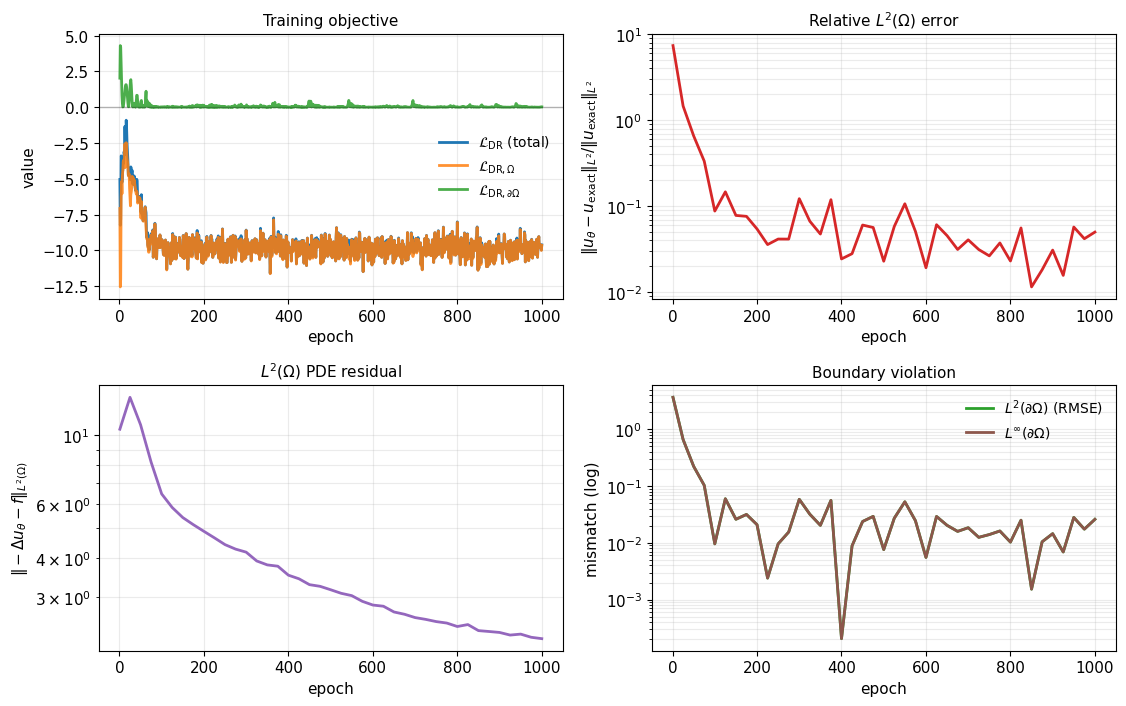

In [19]:
# 2D Poisson: Yu & E–style diagnostics (NumPy + matplotlib only)
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

H2 = hist_poisson_2d

loss_total = H2['losses_total']
loss_int = H2['losses_int']
loss_bc = H2['losses_bc']
epochs_arr = np.arange(1, loss_total.size + 1)

ep2 = H2['diag_epochs']
rel_l2_2d = H2['rel_l2']
pde_res_l2_2d = H2['pde_res_l2']
bc_l2_2d = H2['bc_l2']
bc_linf_2d = H2['bc_linf']

mpl.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

eps_plot = 1e-16
fig, axes = plt.subplots(2, 2, figsize=(11.4, 7.2))

# 1) Training objective value (note: Ritz energies can be negative)
ax = axes[0, 0]
ax.plot(epochs_arr, loss_total, color='C0', label=r'$\mathcal{L}_{\mathrm{DR}}$ (total)')
ax.plot(epochs_arr, loss_int, color='C1', alpha=0.85, label=r'$\mathcal{L}_{\mathrm{DR},\Omega}$')
ax.plot(epochs_arr, loss_bc, color='C2', alpha=0.85, label=r'$\mathcal{L}_{\mathrm{DR},\partial\Omega}$')
ax.axhline(0.0, color='k', lw=1.0, alpha=0.25)
ax.set_title('Training objective')
ax.set_xlabel('epoch')
ax.set_ylabel('value')
ax.grid(True, alpha=0.25)
ax.legend(loc='best', frameon=False)

# 2) Relative L2 error
ax = axes[0, 1]
ax.semilogy(ep2, np.maximum(rel_l2_2d, eps_plot), color='C3')
ax.set_title(r'Relative $L^2(\Omega)$ error')
ax.set_xlabel('epoch')
ax.set_ylabel(r'$\|u_\theta-u_{\mathrm{exact}}\|_{L^2}/\|u_{\mathrm{exact}}\|_{L^2}$')
ax.grid(True, which='both', alpha=0.25)

# 3) PDE residual norm
ax = axes[1, 0]
ax.semilogy(ep2, np.maximum(pde_res_l2_2d, eps_plot), color='C4')
ax.set_title(r'$L^2(\Omega)$ PDE residual')
ax.set_xlabel('epoch')
ax.set_ylabel(r'$\| -\Delta u_\theta - f \|_{L^2(\Omega)}$')
ax.grid(True, which='both', alpha=0.25)

# 4) Boundary mismatch norms
ax = axes[1, 1]
ax.semilogy(ep2, np.maximum(bc_l2_2d, eps_plot), color='C2', label=r'$L^2(\partial\Omega)$ (RMSE)')
ax.semilogy(ep2, np.maximum(bc_linf_2d, eps_plot), color='C5', label=r'$L^\infty(\partial\Omega)$')
ax.set_title('Boundary violation')
ax.set_xlabel('epoch')
ax.set_ylabel('mismatch (log)')
ax.grid(True, which='both', alpha=0.25)
ax.legend(loc='best', frameon=False)

fig.tight_layout()
plt.show()

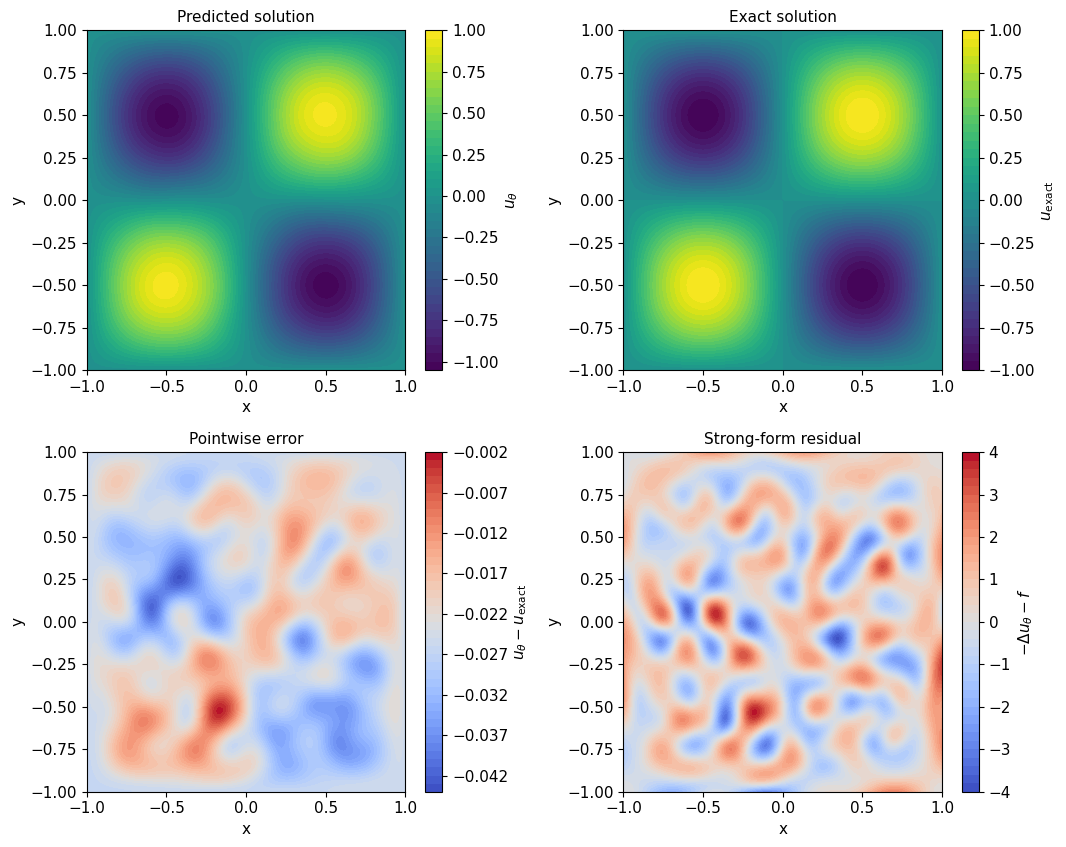

In [ ]:
# 2D Poisson: visualize u_theta vs u_exact (and error/residual)
import numpy as np
import matplotlib.pyplot as plt

xv = np.linspace(-1.0, 1.0, 161)
yv = np.linspace(-1.0, 1.0, 161)
Xv, Yv = np.meshgrid(xv, yv, indexing='xy')
x_flat = Xv.reshape(-1)
y_flat = Yv.reshape(-1)

a_viz = hist_poisson_2d['a_readout']
u, _, _, u_xx, u_yy = eval_u_and_derivatives(
    model_poisson_2d, x_flat, y_flat, a_readout=a_viz, cache_fields=True,
    embed_x_scale=float(hist_poisson_2d.get('embed_x_scale', 0.7)),
    embed_y_scale=float(hist_poisson_2d.get('embed_y_scale', 0.7)),
    embed_bias=float(hist_poisson_2d.get('embed_bias', 1.0)),
 )
u_pred = u.reshape(Yv.shape)
u_true = u_exact_square_sin(Xv, Yv)
err = u_pred - u_true
res = (-(u_xx + u_yy) - f_square_sin(x_flat, y_flat)).reshape(Yv.shape)

fig, axes = plt.subplots(2, 2, figsize=(10.8, 8.6))

ax = axes[0, 0]
im = ax.contourf(Xv, Yv, u_pred, levels=40, cmap='viridis')
fig.colorbar(im, ax=ax, label=r'$u_\theta$')
ax.set_title('Predicted solution')
ax.set_xlabel('x'); ax.set_ylabel('y')

ax = axes[0, 1]
im = ax.contourf(Xv, Yv, u_true, levels=40, cmap='viridis')
fig.colorbar(im, ax=ax, label=r'$u_{\mathrm{exact}}$')
ax.set_title('Exact solution')
ax.set_xlabel('x'); ax.set_ylabel('y')

ax = axes[1, 0]
im = ax.contourf(Xv, Yv, err, levels=40, cmap='coolwarm')
fig.colorbar(im, ax=ax, label=r'$u_\theta-u_{\mathrm{exact}}$')
ax.set_title('Pointwise error')
ax.set_xlabel('x'); ax.set_ylabel('y')


ax = axes[1, 1]
im = ax.contourf(Xv, Yv, res, levels=40, cmap='coolwarm')
fig.colorbar(im, ax=ax, label=r'$-\Delta u_\theta - f$')
ax.set_title('Strong-form residual')
ax.set_xlabel('x'); ax.set_ylabel('y')

fig.tight_layout()
plt.show()